# Brownian Motion and Related Processes

This notebook introduces the simulation of standard Brownian motion and several related constructions. It includes the original ideas of this project—sample paths, a midpoint construction, a Brownian bridge, Brownian motion with drift and volatility, and an empirical comparison with Apple stock data—together with a more rigorous mathematical structure and reproducible simulations.

The main goal is to connect the mathematical definition of these stochastic processes with numerical simulation.

## 1. Standard Brownian Motion

A **standard Brownian motion** $W=(W_t)_{t\ge 0}$ is a stochastic process satisfying, among other properties,

$$
W_0=0,\qquad W_t-W_s\sim\mathcal N(0,t-s),\quad 0\le s<t,
$$

and increments over disjoint time intervals are independent.

To simulate a path on $[0,T]$, divide the interval into $n$ subintervals of length

$$
\Delta t=\frac{T}{n}.
$$

If $Z_k\sim\mathcal N(0,1)$ are independent, then

$$
W_{t_{k+1}}=W_{t_k}+\sqrt{\Delta t}\,Z_k.
$$

This is the discrete construction used throughout the notebook.

In [16]:
import matplotlib.pyplot as plt
import numpy as np

In [17]:
def brownian_motion(T, n, seed=None):
    """Simulate one standard Brownian motion path on [0, T]."""
    if T <= 0:
        raise ValueError("T must be positive.")
    if n <= 0 or int(n) != n:
        raise ValueError("n must be a positive integer.")

    n = int(n)
    dt = T / n
    time = np.linspace(0, T, n + 1)

    rng = np.random.default_rng(seed)
    increments = np.sqrt(dt) * rng.normal(0, 1, n)

    path = np.empty(n + 1)
    path[0] = 0
    path[1:] = np.cumsum(increments)

    return time, path


def brown(T, n, seed=None):
    """Backward-compatible wrapper returning only the Brownian path."""
    _, path = brownian_motion(T, n, seed=seed)
    return path.tolist()

### A single sample path

The following cell simulates one realization of $W_t$ and plots it.

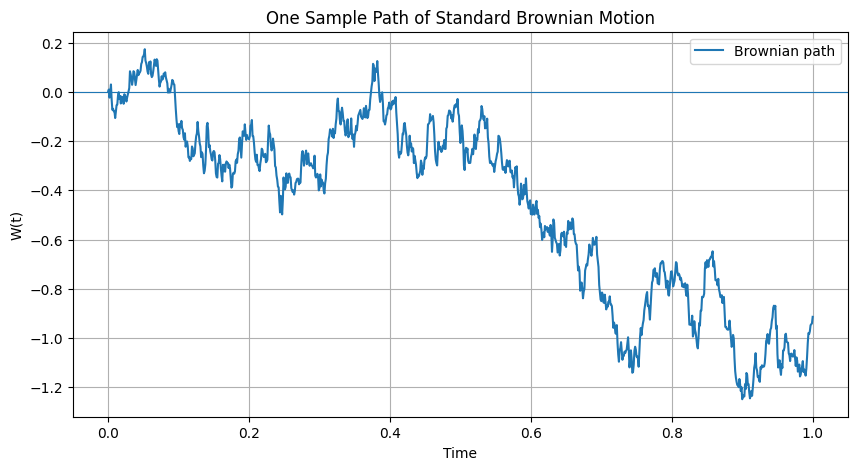

In [18]:
T = 1
n = 1000

time, path = brownian_motion(T, n, seed=42)

plt.figure(figsize=(10, 5))
plt.plot(time, path, label="Brownian path")
plt.axhline(0, linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("W(t)")
plt.title("One Sample Path of Standard Brownian Motion")
plt.legend()
plt.grid(True)
plt.show()

## 2. Several Brownian Paths and Typical Scale

The standard deviation of $W_t$ is $\sqrt{t}$. Therefore, $\pm\sqrt{t}$ provide a useful visual reference for the typical scale of the process (they are **not** hard bounds on the paths).

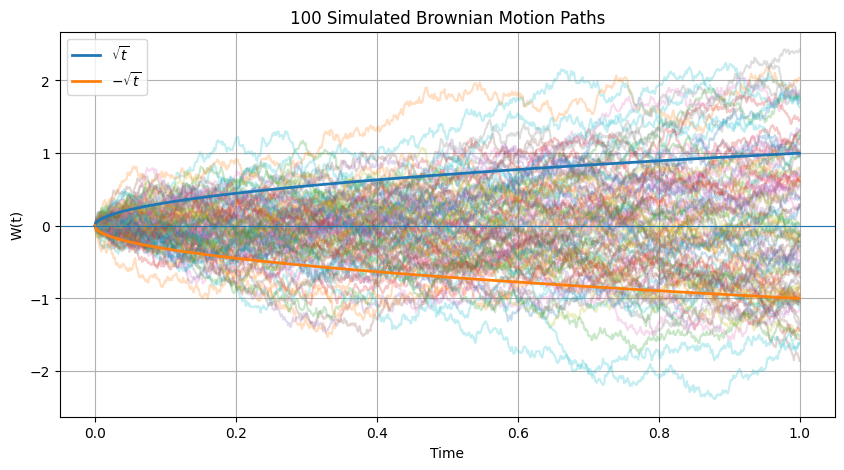

In [19]:
T = 1
n = 1000
n_paths = 100

rng = np.random.default_rng(123)
dt = T / n
time = np.linspace(0, T, n + 1)

increments = np.sqrt(dt) * rng.normal(0, 1, size=(n_paths, n))
paths = np.zeros((n_paths, n + 1))
paths[:, 1:] = np.cumsum(increments, axis=1)

plt.figure(figsize=(10, 5))
for path in paths:
    plt.plot(time, path, alpha=0.25)

plt.plot(time, np.sqrt(time), linewidth=2, label=r"$\sqrt{t}$")
plt.plot(time, -np.sqrt(time), linewidth=2, label=r"$-\sqrt{t}$")
plt.axhline(0, linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("W(t)")
plt.title("100 Simulated Brownian Motion Paths")
plt.legend()
plt.grid(True)
plt.show()

### Distribution at a fixed time

For standard Brownian motion,

$$
W_T\sim\mathcal N(0,T).
$$

We can check this numerically by simulating many terminal values.

Empirical mean: -0.0037
Theoretical mean: 0.0000
Empirical variance: 0.9831
Theoretical variance: 1.0000


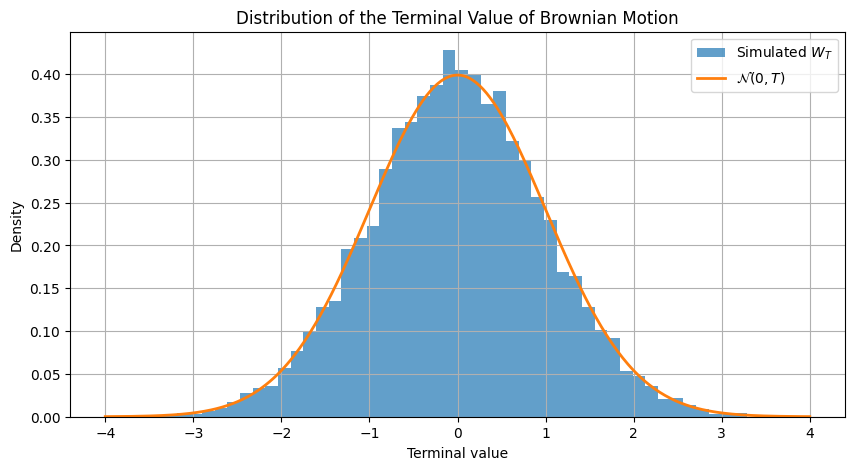

In [20]:
T = 1
n = 1000
n_paths = 10000

rng = np.random.default_rng(2026)
dt = T / n
terminal_values = np.sum(np.sqrt(dt) * rng.normal(0, 1, size=(n_paths, n)), axis=1)

print(f"Empirical mean: {terminal_values.mean():.4f}")
print(f"Theoretical mean: 0.0000")
print(f"Empirical variance: {terminal_values.var():.4f}")
print(f"Theoretical variance: {T:.4f}")

plt.figure(figsize=(10, 5))
plt.hist(terminal_values, bins=50, density=True, alpha=0.7, label=r"Simulated $W_T$")

x = np.linspace(-4 * np.sqrt(T), 4 * np.sqrt(T), 400)
density = np.exp(-x**2 / (2 * T)) / np.sqrt(2 * np.pi * T)
plt.plot(x, density, linewidth=2, label=r"$\mathcal{N}(0,T)$")

plt.xlabel("Terminal value")
plt.ylabel("Density")
plt.title("Distribution of the Terminal Value of Brownian Motion")
plt.legend()
plt.grid(True)
plt.show()

## 3. Midpoint Refinement

A midpoint should not simply be the deterministic average of the endpoints: conditioned on $W_{t_i}$ and $W_{t_{i+1}}$, the midpoint is random.

For $m=(t_i+t_{i+1})/2$,

$$
W_m\mid W_{t_i},W_{t_{i+1}}\sim\mathcal N\left(\frac{W_{t_i}+W_{t_{i+1}}}{2},\frac{t_{i+1}-t_i}{4}\right).
$$

Thus, if $\Delta t=t_{i+1}-t_i$, the conditional midpoint can be simulated as

$$
W_m=\frac{W_{t_i}+W_{t_{i+1}}}{2}+\frac{\sqrt{\Delta t}}{2}Z,\qquad Z\sim\mathcal N(0,1).
$$

This corrects the original midpoint experiment while preserving its purpose.

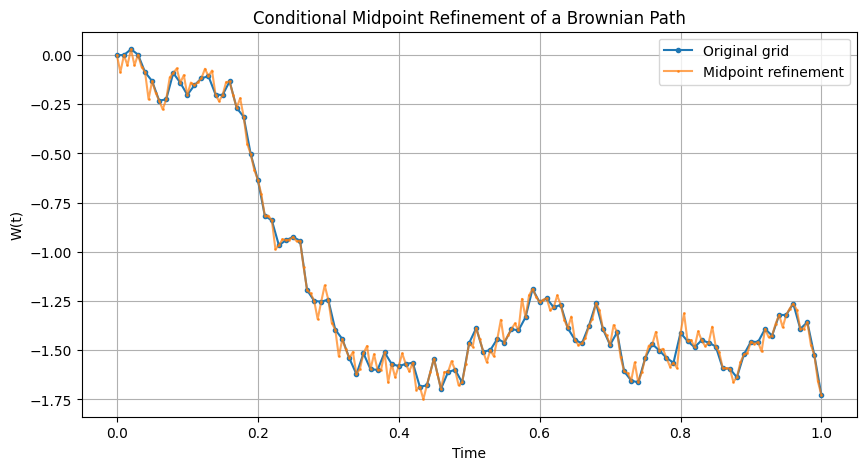

In [21]:
def refine_with_midpoints(time, path, seed=None):
    """Insert Brownian midpoint samples conditioned on the existing endpoints."""
    if len(time) != len(path):
        raise ValueError("time and path must have the same length.")
    if len(time) < 2:
        raise ValueError("At least two time points are required.")

    rng = np.random.default_rng(seed)
    refined_time = []
    refined_path = []

    for i in range(len(time) - 1):
        t0, t1 = time[i], time[i + 1]
        w0, w1 = path[i], path[i + 1]
        dt = t1 - t0
        tm = (t0 + t1) / 2
        wm = (w0 + w1) / 2 + np.sqrt(dt) * rng.normal() / 2

        refined_time.extend([t0, tm])
        refined_path.extend([w0, wm])

    refined_time.append(time[-1])
    refined_path.append(path[-1])

    return np.array(refined_time), np.array(refined_path)


coarse_time, coarse_path = brownian_motion(1, 100, seed=7)
refined_time, refined_path = refine_with_midpoints(coarse_time, coarse_path, seed=8)

plt.figure(figsize=(10, 5))
plt.plot(coarse_time, coarse_path, "o-", markersize=3, label="Original grid")
plt.plot(refined_time, refined_path, ".-", markersize=2, alpha=0.7, label="Midpoint refinement")
plt.xlabel("Time")
plt.ylabel("W(t)")
plt.title("Conditional Midpoint Refinement of a Brownian Path")
plt.legend()
plt.grid(True)
plt.show()

## 4. Brownian Bridge

A Brownian bridge from $0$ to $0$ over $[0,T]$ can be obtained from a Brownian motion through

$$
B_t=W_t-\frac{t}{T}W_T.
$$

Since $B_0=0$ and $B_T=0$, the resulting process is pinned at both endpoints. More generally, to construct a bridge from $0$ to a prescribed endpoint $b$, use

$$
B_t=W_t+\frac{t}{T}(b-W_T).
$$

The implementation below supports both cases.

In [22]:
def brownian_bridge(T, n, endpoint=0.0, seed=None):
    """Simulate a Brownian bridge from 0 to endpoint over [0, T]."""
    time, path = brownian_motion(T, n, seed=seed)
    bridge = path + (time / T) * (endpoint - path[-1])
    return time, bridge



def BrownBridge(path):
    """Convert a Brownian path that starts at zero into a bridge ending at zero."""
    path = np.asarray(path, dtype=float)
    if len(path) < 2:
        raise ValueError("The path must contain at least two points.")

    n = len(path) - 1
    time_fraction = np.arange(n + 1) / n
    return path - time_fraction * path[-1]

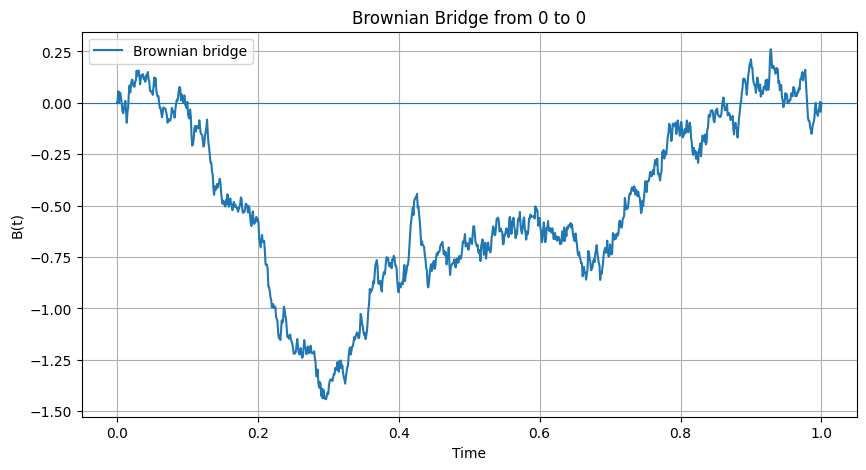

In [23]:
time, bridge = brownian_bridge(1, 1000, endpoint=0, seed=21)

plt.figure(figsize=(10, 5))
plt.plot(time, bridge, label="Brownian bridge")
plt.axhline(0, linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("B(t)")
plt.title("Brownian Bridge from 0 to 0")
plt.legend()
plt.grid(True)
plt.show()

### Several Brownian bridges

Unlike ordinary Brownian motion, every bridge in the next simulation is forced to start and end at the prescribed values.

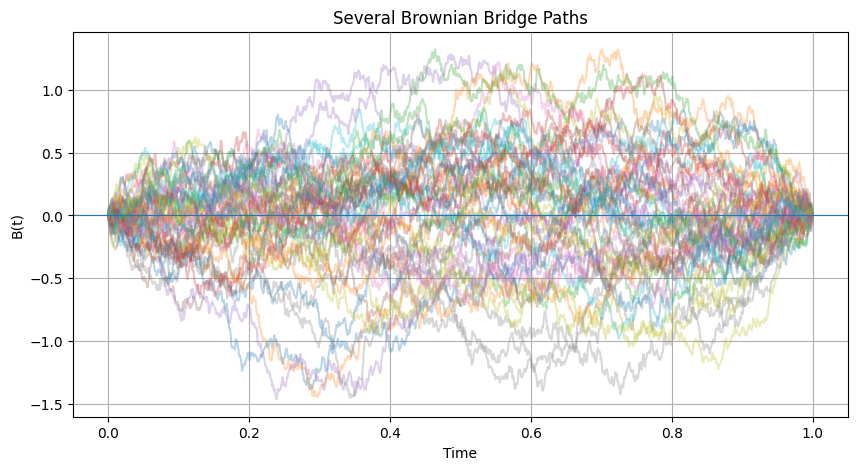

In [24]:
T = 1
n = 1000
n_paths = 50

plt.figure(figsize=(10, 5))
for seed in range(n_paths):
    time, bridge = brownian_bridge(T, n, endpoint=0, seed=seed)
    plt.plot(time, bridge, alpha=0.3)

plt.axhline(0, linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("B(t)")
plt.title("Several Brownian Bridge Paths")
plt.grid(True)
plt.show()

## 5. Brownian Motion with Drift and Volatility

The standard model is

$$
X_t=\mu t+\sigma W_t,
$$

where $\mu$ is the drift and $\sigma>0$ is the volatility. Consequently,

$$
X_t\sim\mathcal N(\mu t,\sigma^2 t).
$$

The code below implements this transformation directly.

In [25]:
def brownian_with_drift(T, n, mu, sigma, seed=None):
    """Simulate X_t = mu*t + sigma*W_t on [0, T]."""
    if sigma < 0:
        raise ValueError("sigma must be non-negative.")

    time, path = brownian_motion(T, n, seed=seed)
    process = mu * time + sigma * path
    return time, process


# This wrapper preserves the structure of the original BrownDrift function.
def BrownDrift(path, mu, sigma):
    """Apply drift and volatility to an existing Brownian path."""
    path = np.asarray(path, dtype=float)
    n = len(path) - 1
    time = np.arange(n + 1) / n
    return mu * time + sigma * path

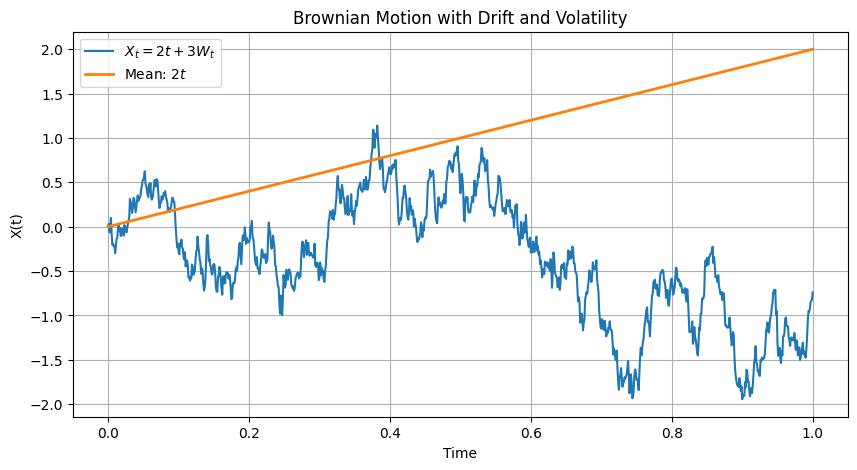

In [26]:
T = 1
n = 1000
mu = 2
sigma = 3

time, drift_process = brownian_with_drift(T, n, mu, sigma, seed=42)

plt.figure(figsize=(10, 5))
plt.plot(time, drift_process, label=fr"$X_t={mu}t+{sigma}W_t$")
plt.plot(time, mu * time, linewidth=2, label=fr"Mean: ${mu}t$")
plt.xlabel("Time")
plt.ylabel("X(t)")
plt.title("Brownian Motion with Drift and Volatility")
plt.legend()
plt.grid(True)
plt.show()

## 6. Empirical Comparison with Apple Stock Data
A stock-price series is **not** itself a Brownian motion. A more meaningful comparison is to study log-returns, whose behavior can be approximated by models based on Brownian motion.

In [27]:
try:
    import yfinance as yf
except ImportError:
    yf = None
    print("yfinance is not installed. Run `pip install yfinance` to enable this section.")

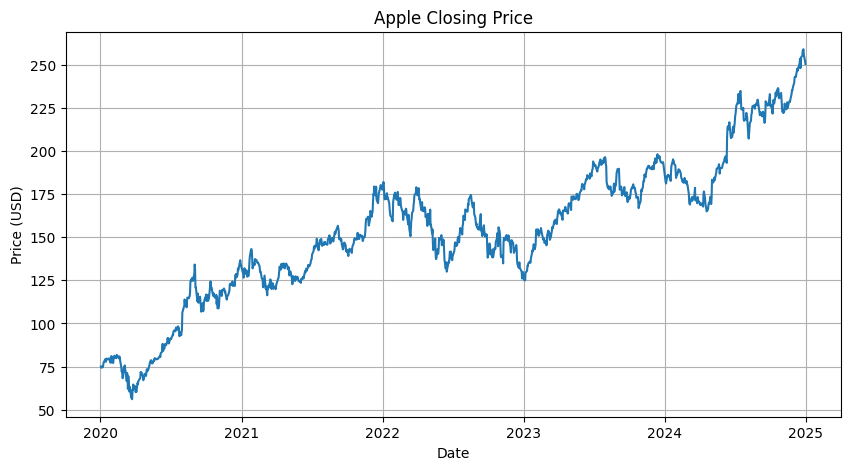

In [28]:
if yf is not None:
    apple = yf.download(
        "AAPL",
        start="2020-01-01",
        end="2025-01-01",
        auto_adjust=False,
        progress=False
    )

    close = apple["Close"]
    if hasattr(close, "columns"):
        close = close.iloc[:, 0]

    plt.figure(figsize=(10, 5))
    plt.plot(close.index, close)
    plt.title("Apple Closing Price")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.grid(True)
    plt.show()

Mean daily log-return: 0.000958
Daily volatility: 0.019942


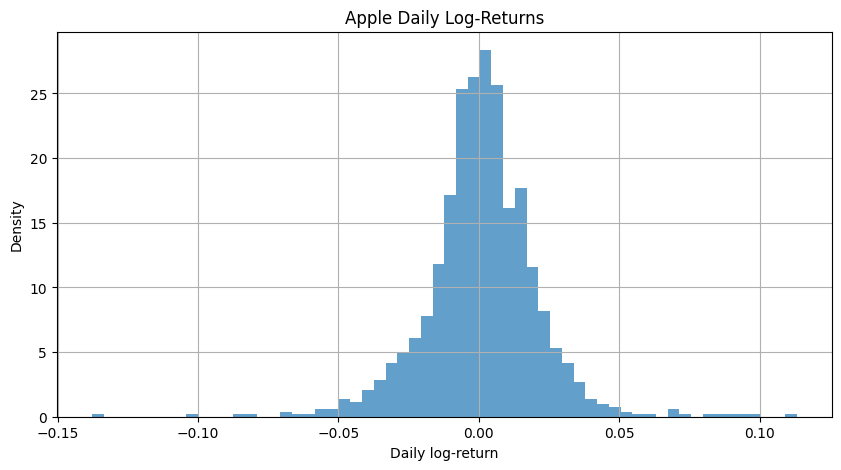

In [29]:
if yf is not None:
    log_returns = np.log(close / close.shift(1)).dropna()

    print(f"Mean daily log-return: {log_returns.mean():.6f}")
    print(f"Daily volatility: {log_returns.std():.6f}")

    plt.figure(figsize=(10, 5))
    plt.hist(log_returns, bins=60, density=True, alpha=0.7)
    plt.xlabel("Daily log-return")
    plt.ylabel("Density")
    plt.title("Apple Daily Log-Returns")
    plt.grid(True)
    plt.show()

## 7. Main Takeaways

- Brownian motion can be simulated by adding independent normal increments with variance $\Delta t$.
- At a fixed time $T$, $W_T\sim\mathcal N(0,T)$.
- Conditional midpoint sampling gives a principled way to refine a Brownian path.
- A Brownian bridge is a Brownian motion conditioned on its endpoint.
- Adding $\mu t$ and multiplying by $\sigma$ produces the process $X_t=\mu t+\sigma W_t$..
- Financial data can be compared with Brownian-based models, but observed stock prices should not be identified with Brownian motion itself.

The simulations above connect the theoretical definitions with concrete numerical realizations.